# Electricity price floor & asymmetry techniques comparison

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

current_dir = Path.cwd()
project_root = None
if (current_dir / 'config.py').exists():
    project_root = str(current_dir)
elif (current_dir.parent / 'config.py').exists():
    project_root = str(current_dir.parent)

if project_root and project_root not in sys.path:
    sys.path.insert(0, project_root)

from models import (
    ProbabilisticTransformer,
    HybridProbabilisticTransformer,
    HybridProbabilisticTransformerOUJump,
    HybridProbabilisticTransformerHourlyOU,
    HybridProbabilisticTransformerSoftBarrierOU,
    HybridProbabilisticTransformerAsymmetricJump,
)
from core.experiment_utils import (
    load_data, load_cache, save_cache, run_experiment, N_RUNS,
)

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

try:
    gpus = tf.config.experimental.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs detected: {len(gpus)}")
except Exception as e:
    print(f"GPU config failed: {e}")

2026-03-08 09:09:49.329566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772957389.420039  668196 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772957389.445767  668196 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772957389.603046  668196 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772957389.603064  668196 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772957389.603066  668196 computation_placer.cc:177] computation placer alr

GPUs detected: 1


In [2]:
RESULTS_DIR = Path(project_root) / "results" / "price_floor_comparison"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = RESULTS_DIR / "results.json"

In [3]:
# All metrics and caching handled by core.experiment_utils

In [4]:
data = load_data()

Data loaded  —  Train: 10367, Val: 1997, Test: 1128


In [5]:
# Model configurations: (display_name, model_class, head_type, head_params, is_hybrid, apply_posthoc_floor)
# Added: Soft Barrier OU (soft floor near zero), Asymmetric Jump (larger upward spikes).
MODEL_CONFIGS = [
    ("Baseline (Gaussian)", ProbabilisticTransformer, "gaussian", {}, False, False),
    ("Baseline (Johnson SU)", ProbabilisticTransformer, "johnson_su", {}, False, False),
    ("Johnson SU + Floor", ProbabilisticTransformer, "johnson_su_floor", {"floor_penalty_weight": 0.1, "asymmetric_weight": 1.5}, False, False),
    ("Hybrid (Transformer+OU)", HybridProbabilisticTransformer, "johnson_su", {}, True, False),
    ("Hybrid + OU + Jump", HybridProbabilisticTransformerOUJump, "johnson_su", {}, True, False),
    ("Hybrid + Hourly OU", HybridProbabilisticTransformerHourlyOU, "johnson_su", {"hour_col_idx": 1}, True, False),
    ("Hybrid + Soft Barrier OU", HybridProbabilisticTransformerSoftBarrierOU, "johnson_su", {}, True, False),
    ("Hybrid + Asymmetric Jump", HybridProbabilisticTransformerAsymmetricJump, "johnson_su", {}, True, False),
]

In [6]:
cache = load_cache(CACHE_FILE)

for model_name, model_cls, head_type, head_params, is_hybrid, apply_posthoc_floor in MODEL_CONFIGS:
    run_experiment(
        model_cls, model_name, data,
        str(RESULTS_DIR),
        cache=cache,
        is_hybrid=is_hybrid,
        head_type=head_type,
        head_params=head_params,
    )

save_cache(CACHE_FILE, cache)
print("\nAll experiments complete.")

[Baseline (Gaussian)] found in cache — skipping.
[Baseline (Johnson SU)] found in cache — skipping.
[Johnson SU + Floor] found on disk (/home/d1ff1cult/masterproef_new/results/price_floor_comparison/Johnson_SU_+_Floor/summary.json) — skipping.
[Hybrid (Transformer+OU)] found on disk (/home/d1ff1cult/masterproef_new/results/price_floor_comparison/Hybrid_(Transformer+OU)/summary.json) — skipping.
[Hybrid + OU + Jump] found on disk (/home/d1ff1cult/masterproef_new/results/price_floor_comparison/Hybrid_+_OU_+_Jump/summary.json) — skipping.

  Experiment: Hybrid + Hourly OU
  Model: HybridProbabilisticTransformerHourlyOU  |  head: johnson_su  |  runs: 10
  Run 1/10 ...


I0000 00:00:1772957395.812211  668196 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7483 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1


Epoch 1/30


2026-03-08 09:09:56.767318: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 195065472 exceeds 10% of free system memory.
2026-03-08 09:09:56.895997: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 195065472 exceeds 10% of free system memory.
I0000 00:00:1772957402.187184  668456 service.cc:152] XLA service 0x70d530002180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772957402.187199  668456 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1080, Compute Capability 6.1
2026-03-08 09:10:02.382149: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772957403.420360  668456 cuda_dnn.cc:529] Loaded cuDNN version 90300


  7/324 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 1.6274

...

324/324 ━━━━━━━━━━━━━━━━━━━━ 36s 66ms/step - loss: 1.0834 - val_loss: 1.0861 - learning_rate: 7.0000e-04
Epoch 2/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.7453 - val_loss: 0.9535 - learning_rate: 7.0000e-04
Epoch 3/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.5902 - val_loss: 0.9547 - learning_rate: 7.0000e-04
Epoch 4/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.4933 - val_loss: 1.0249 - learning_rate: 7.0000e-04
Epoch 5/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.4172 - val_loss: 1.2850 - learning_rate: 7.0000e-04
Epoch 6/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.3627 - val_loss: 1.2082 - learning_rate: 7.0000e-04
Epoch 7/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.3165 - val_loss: 1.2132 - learning_rate: 7.0000e-04
Fitting Hourly OU (24 processes)...


2026-03-08 09:11:33.137766: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 195065472 exceeds 10% of free system memory.
2026-03-08 09:11:33.262624: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 195065472 exceeds 10% of free system memory.


  Fitted 24 hourly OU processes.
  Run 2/10 ...
Epoch 1/30


2026-03-08 09:15:39.361447: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 195065472 exceeds 10% of free system memory.


324/324 ━━━━━━━━━━━━━━━━━━━━ 34s 63ms/step - loss: 1.0807 - val_loss: 1.1871 - learning_rate: 7.0000e-04
Epoch 2/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.7467 - val_loss: 0.8806 - learning_rate: 7.0000e-04
Epoch 3/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.5817 - val_loss: 1.0223 - learning_rate: 7.0000e-04
Epoch 4/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.4815 - val_loss: 0.9939 - learning_rate: 7.0000e-04
Epoch 5/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.4138 - val_loss: 1.0944 - learning_rate: 7.0000e-04
Epoch 6/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.3640 - val_loss: 1.1921 - learning_rate: 7.0000e-04
Epoch 7/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.3111 - val_loss: 1.1532 - learning_rate: 7.0000e-04
Fitting Hourly OU (24 processes)...
  Fitted 24 hourly OU processes.
  Run 3/10 ...
Epoch 1/30
324/324 ━━━━━━━━━━━━━━━━━━━━ 34s 63ms/step - loss: 1.0874 - val_loss: 1.1337 - learning_rate: 7.0000e-04

In [7]:
# Results summary
results = []
for model_name, metrics in cache.items():
    results.append({"Model": model_name, **metrics})

df_res = pd.DataFrame(results)
if not df_res.empty:
    df_sorted = df_res.sort_values("MAE")
    display(df_sorted)
    df_sorted.to_csv(RESULTS_DIR / "comparison_summary.csv", index=False)
    print(f"\nResults saved to {RESULTS_DIR / 'comparison_summary.csv'}")

,Model,MAE,RMSE,MAPE,R2,Pinball_10,Pinball_50,Pinball_90,Avg_Pinball,PICP,MPIW,PINAW,IntervalScore,CRPS,MSE,NLL,training_time
6,Hybrid + Soft Barrier OU,21.629241,29.215070,6039.872195,0.525461,5.668775,11.109841,5.144473,7.307696,0.925473,113.018226,0.352697,164.571977,16.243828,857.588844,NaN,103.487965
3,Hybrid (Transformer+OU),21.768582,29.060964,5838.877423,0.532185,5.661389,11.032564,5.041434,7.245129,0.910383,104.866487,0.327258,163.781308,16.097704,845.437779,NaN,108.592753
4,Hybrid + OU + Jump,22.020205,29.402854,5816.767262,0.520688,5.714762,11.148670,5.081797,7.315076,0.917317,108.488398,0.338561,164.026019,16.255386,866.214093,NaN,103.495789
5,Hybrid + Hourly OU,22.112191,29.512933,5729.124761,0.517504,5.521352,11.138932,5.334711,7.331665,0.938531,120.718577,0.376728,163.196146,16.304848,871.968966,NaN,108.313760
7,Hybrid + Asymmetric Jump,24.191597,31.631385,6524.846225,0.444830,5.729826,15.020262,10.943264,10.564451,0.992387,265.682545,0.829118,269.515591,22.955017,1003.306140,NaN,102.009556
2,Johnson SU + Floor,24.242319,32.362530,8485.218679,0.394663,6.294812,12.194592,5.319804,7.936403,0.935963,125.447264,0.391484,170.806162,17.943649,1093.967819,49.853055,129.410864
1,Baseline (Johnson SU),24.795829,33.671737,864.640832,0.141594,5.718921,12.153882,7.637595,8.503466,0.782752,80.555804,0.196277,243.855131,18.541428,NaN,NaN,NaN
0,Baseline (Gaussian),25.422495,33.588177,820.875575,0.144249,5.704122,12.711247,6.370456,8.261942,0.848123,90.116015,0.219570,191.706586,18.483009,NaN,NaN,NaN



Results saved to /home/d1ff1cult/masterproef_new/results/price_floor_comparison/comparison_summary.csv


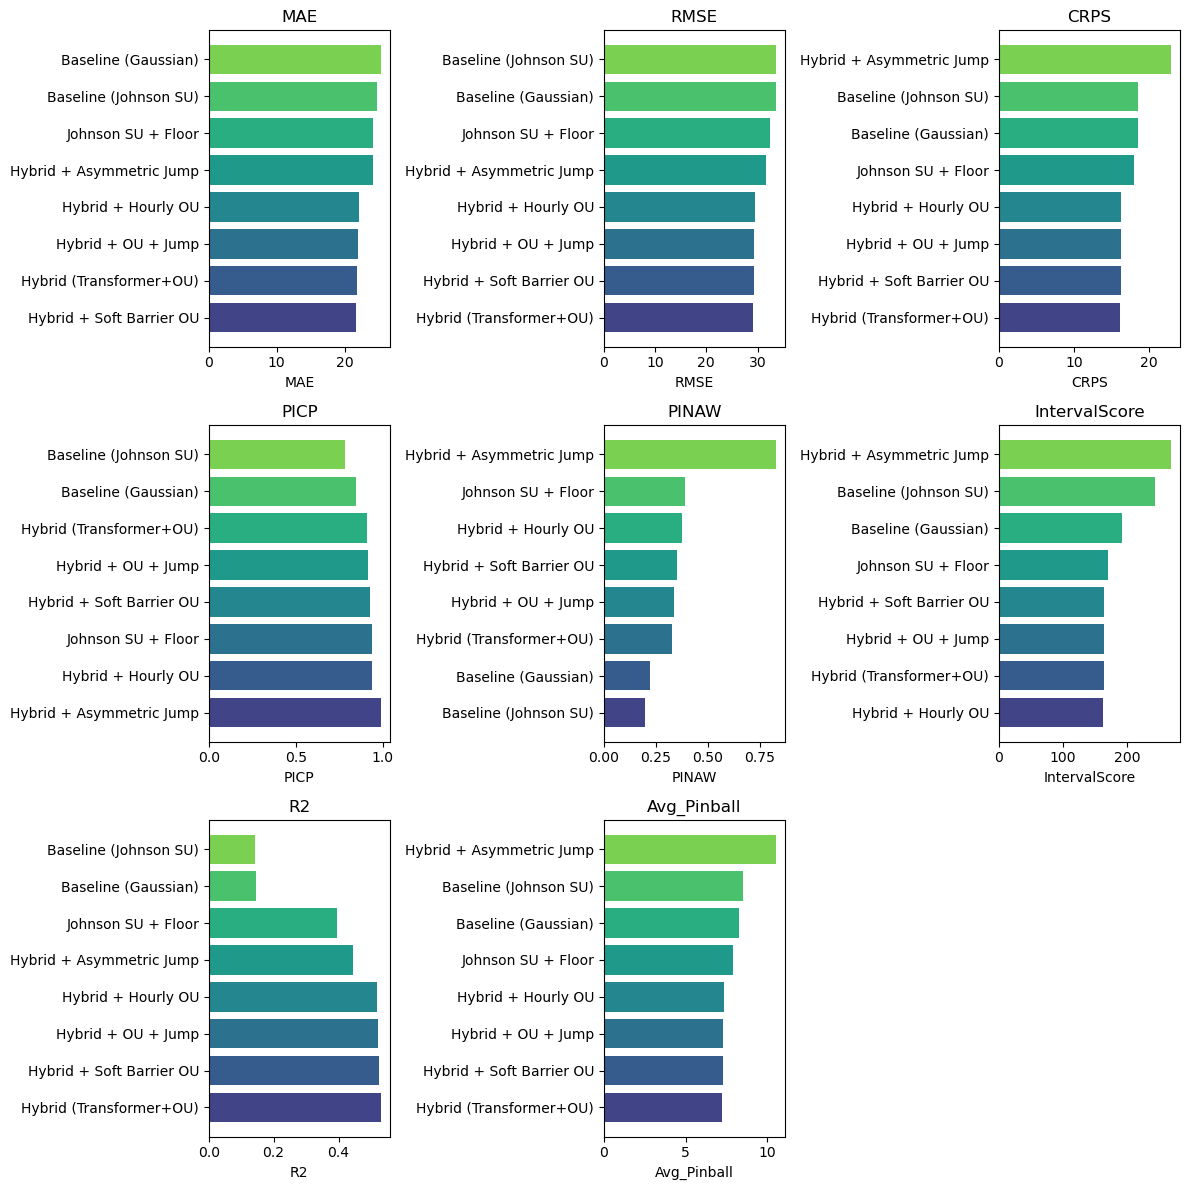

Plot saved to /home/d1ff1cult/masterproef_new/results/price_floor_comparison/comparison_charts.png


In [8]:
# Bar charts for key metrics
if not df_res.empty:
    import matplotlib.pyplot as plt

    metrics_to_plot = ["MAE", "RMSE", "CRPS", "PICP", "PINAW", "IntervalScore", "R2", "Avg_Pinball"]
    metrics_avail = [m for m in metrics_to_plot if m in df_res.columns]
    n_plots = len(metrics_avail)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for ax, metric in zip(axes[:n_plots], metrics_avail):
        ascending = metric not in ("R2", "PICP")
        df_plot = df_res.sort_values(metric, ascending=ascending)
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(df_plot)))
        ax.barh(df_plot["Model"], df_plot[metric], color=colors)
        ax.set_xlabel(metric)
        ax.set_title(metric)

    for ax in axes[n_plots:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "comparison_charts.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to {RESULTS_DIR / 'comparison_charts.png'}")